# AEP [Calvin - Samuel]

In [27]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install prophet


Note: you may need to restart the kernel to use updated packages.


## Using Prophet

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("../data/datasets/AEP_hourly.csv", parse_dates=['Datetime'])
data = data.rename(columns={"Datetime": "ds", "AEP_MW": "y"})

# Filter data train: 2015-01-01 sampai 2017-12-31
train = data[(data['ds'] >= '2015-01-01') & (data['ds'] <= '2017-12-31')]

# Filter data test: 2018-01-01 sampai 2018-12-31
test = data[(data['ds'] >= '2018-01-01') & (data['ds'] <= '2018-12-31')]

print("Data train:", train.shape)
print("Data test:", test.shape)


Data train: (26281, 2)
Data test: (5136, 2)


In [4]:
# Inisialisasi model Prophet
model = Prophet(
    daily_seasonality=True,  # karena hourly data
    yearly_seasonality=True, 
    weekly_seasonality=True
)

# Fit model ke data train
model.fit(train)


16:06:20 - cmdstanpy - INFO - Chain [1] start processing
16:06:39 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
# Forecast untuk periode 2018
future = pd.date_range(start='2018-01-01', end='2018-12-31 23:00:00', freq='H')
future_df = pd.DataFrame({'ds': future})

forecast = model.predict(future_df)


C:\Users\72531\AppData\Local\Temp\ipykernel_25756\300174495.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future = pd.date_range(start='2018-01-01', end='2018-12-31 23:00:00', freq='H')


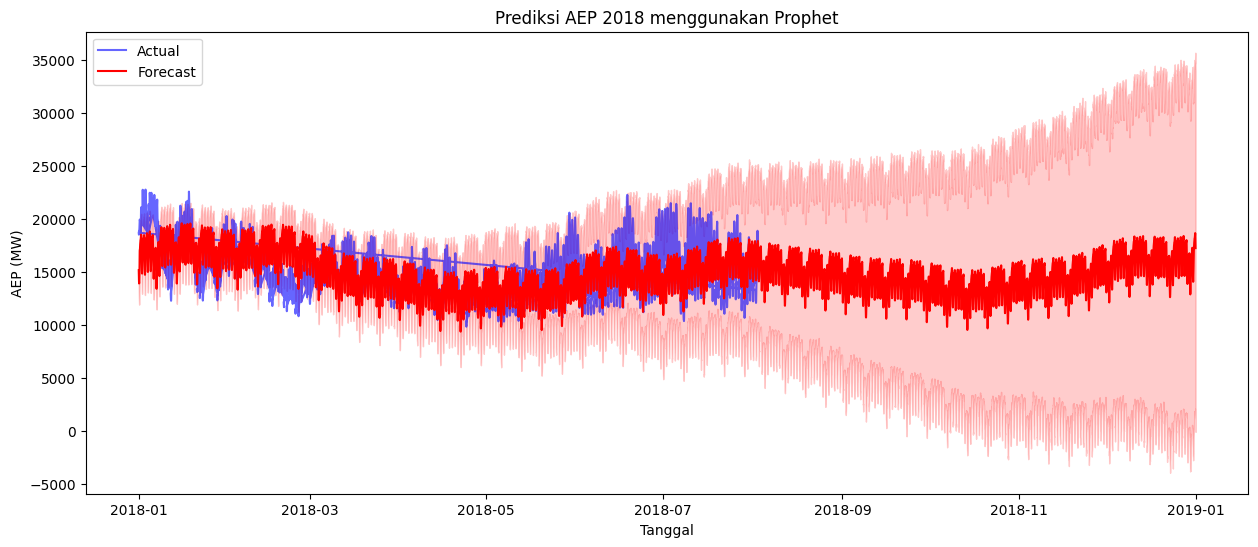

In [6]:
# Plot prediksi vs data aktual
plt.figure(figsize=(15,6))
plt.plot(test['ds'], test['y'], label='Actual', color='blue', alpha=0.6)
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.2)
plt.title("Prediksi AEP 2018 menggunakan Prophet")
plt.xlabel("Tanggal")
plt.ylabel("AEP (MW)")
plt.legend()
plt.show()


In [40]:
# Gabungkan forecast dengan test berdasarkan ds
df_compare = test.merge(forecast[['ds','yhat']], on='ds', how='inner')

# Ambil y aktual dan prediksi yang sudah selaras
y_true = df_compare['y'].values
y_pred = df_compare['yhat'].values

# Hitung RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSE: {rmse:.2f}")


RMSE: 2013.42


In [41]:
# Hitung rata-rata y aktual
y_mean = y_true.mean()

# RMSE dalam persen
rmse_pct = (rmse / y_mean) * 100
print(f"RMSE (%): {rmse_pct:.2f}%")


RMSE (%): 13.17%


In [50]:
# Forecast untuk periode 2018
future = pd.date_range(start='2018-01-01', end='2018-12-31 23:00:00', freq='H')
future_df = pd.DataFrame({'ds': future})

forecast = model.predict(future_df)


C:\Users\72531\AppData\Local\Temp\ipykernel_25756\300174495.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future = pd.date_range(start='2018-01-01', end='2018-12-31 23:00:00', freq='H')


In [51]:
def predict_energy(model, start_date, end_date, freq='H'):
    """Menghasilkan prediksi daya dan dataframe prediksi"""
    future_dates = pd.date_range(start=start_date, end=end_date, freq=freq)
    future_df = pd.DataFrame({'ds': future_dates})
    forecast = model.predict(future_df)
    return forecast


In [52]:
forecast_2018 = predict_energy(model, '2018-01-01', '2018-12-31 23:00:00')


C:\Users\72531\AppData\Local\Temp\ipykernel_25756\4090120638.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start=start_date, end=end_date, freq=freq)


In [53]:
import numpy as np

# dx = 1 jam, MW per jam → MWh
total_energy_2018 = np.trapezoid(forecast_2018['yhat'], dx=1)
print(f"Total energi prediksi 2018: {total_energy_2018:.0f} MWh")

Total energi prediksi 2018: 131947445 MWh


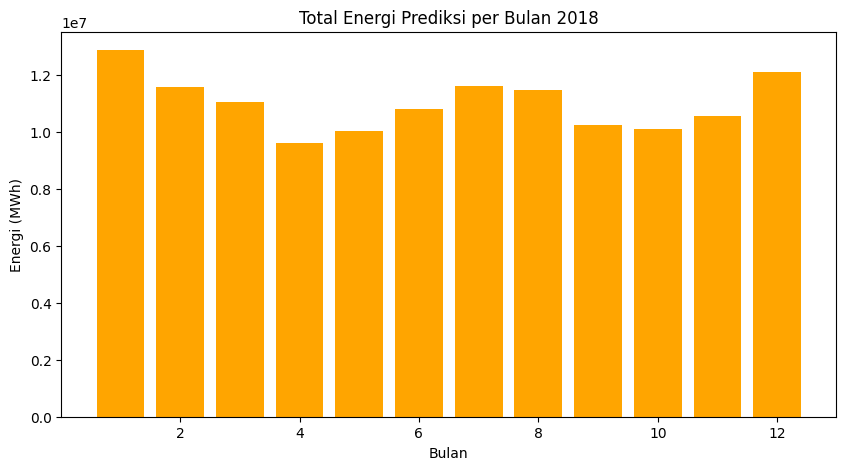

In [47]:
forecast_2018['month'] = forecast_2018['ds'].dt.month
monthly_energy = forecast_2018.groupby('month')['yhat'].sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_energy.index, monthly_energy.values, color='orange')
plt.title("Total Energi Prediksi per Bulan 2018")
plt.xlabel("Bulan")
plt.ylabel("Energi (MWh)")
plt.show()


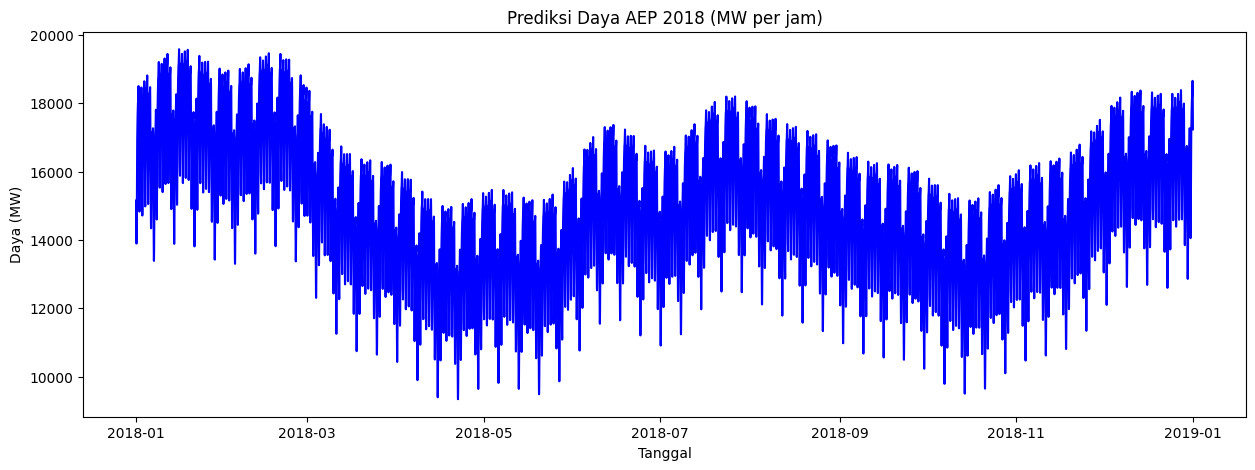

In [18]:
plt.figure(figsize=(15,5))
plt.plot(forecast_2018['ds'], forecast_2018['yhat'], color='blue')
plt.title("Prediksi Daya AEP 2018 (MW per jam)")
plt.xlabel("Tanggal")
plt.ylabel("Daya (MW)")
plt.show()


Prediksi daya jam ke-1000: 17380.53 MW


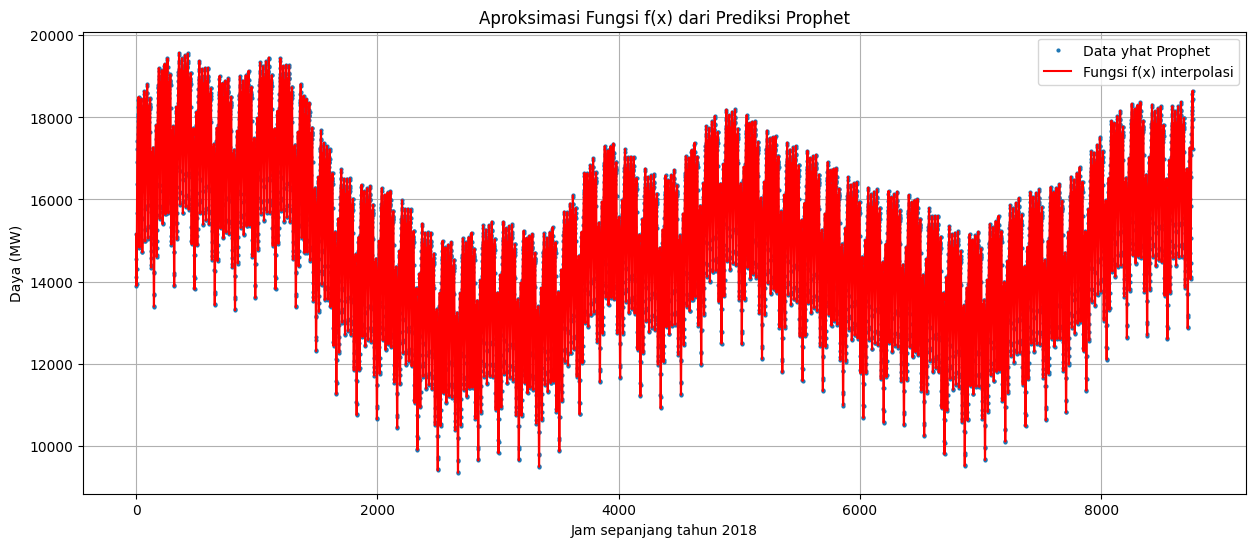

In [19]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# x = index jam sepanjang tahun (0,1,2,...)
x = np.arange(len(forecast_2018))
y = forecast_2018['yhat'].values

# 1️⃣ Buat fungsi f(x) melalui interpolasi
f = interp1d(x, y, kind='cubic')  # cubic spline

# 2️⃣ Contoh penggunaan: prediksi daya pada jam ke-1000
jam_ke = 1000
print(f"Prediksi daya jam ke-{jam_ke}: {f(jam_ke):.2f} MW")

# 3️⃣ Visualisasi fungsi vs data asli
plt.figure(figsize=(15,6))
plt.plot(x, y, 'o', label='Data yhat Prophet', markersize=2)
plt.plot(x, f(x), '-', label='Fungsi f(x) interpolasi', color='red')
plt.title("Aproksimasi Fungsi f(x) dari Prediksi Prophet")
plt.xlabel("Jam sepanjang tahun 2018")
plt.ylabel("Daya (MW)")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from datetime import datetime

# Data prediksi Prophet
x = np.arange(len(forecast_2018))          # indeks jam
y = forecast_2018['yhat'].values           # daya MW
dates = forecast_2018['ds'].values         # tanggal/jam

# Buat fungsi interpolasi berbasis jam
f_interp = interp1d(x, y, kind='cubic')

# Buat mapping datetime → indeks jam
date_to_index = {pd.Timestamp(d): i for i, d in enumerate(dates)}

# Fungsi f(t) menerima string atau datetime
def f(t):
    """
    Mengembalikan prediksi daya (MW) pada datetime t.
    t: str (format 'YYYY-MM-DD HH:MM:SS') atau pd.Timestamp / datetime
    """
    if isinstance(t, str):
        t = pd.Timestamp(t)
    # Cari indeks terdekat
    if t < dates[0] or t > dates[-1]:
        raise ValueError("Datetime di luar range prediksi (2018)")
    # Interpolasi berdasarkan posisi numerik
    # Konversi datetime ke float: hitung selisih jam dari awal
    delta_hours = (t - dates[0]) / np.timedelta64(1, 'h')
    return float(f_interp(delta_hours))

# Contoh pemanggilan
print(f("2018-07-10 15:00:00"))   # Prediksi daya MW
print(f("2018-12-31 23:00:00"))   # Prediksi daya MW terakhir



16713.782591599316
17233.722463537753


### Fungsi

In [30]:
f = interp1d(x, y, kind='cubic')


#### Untuk setiap interval [x[i], x[i+1]], ada persamaan polinomial kubik:
#### f(x)=ai​+bi​(x−xi​)+ci​(x−xi​)2+di​(x−xi​)3untuk x∈[xi​,xi+1​]
#### Koefisien 𝑎𝑖,𝑏𝑖,𝑐𝑖,𝑑𝑖 dihitung otomatis oleh interp1d dari data y.
#### Jadi fungsi tidak punya satu rumus tunggal, tapi sekumpulan polinomial per interval.

In [31]:
f(1000)  # Prediksi daya jam ke-1000


array(17380.5319667)

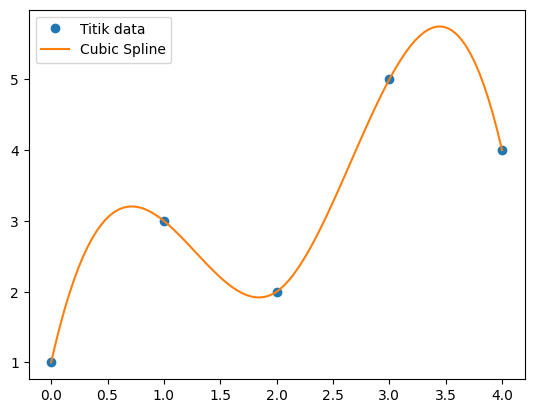

In [32]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# Data
x = np.array([0, 1, 2, 3, 4])
y = np.array([1, 3, 2, 5, 4])

# Cubic Spline
cs = CubicSpline(x, y)

# Visualisasi
xx = np.linspace(0, 4, 100)
plt.plot(x, y, 'o', label='Titik data')
plt.plot(xx, cs(xx), '-', label='Cubic Spline')
plt.legend()
plt.show()

In [33]:
for i in range(len(x)-1):
    print(f"Interval [{x[i]}, {x[i+1]}]:")
    print(f"  f(x) = {cs.c[i,3]:.3f}*(x-{x[i]})^3 + {cs.c[i,2]:.3f}*(x-{x[i]})^2 + {cs.c[i,1]:.3f}*(x-{x[i]}) + {cs.c[i,0]:.3f}")


Interval [0, 1]:
  f(x) = -1.958*(x-0)^3 + -1.958*(x-0)^2 + 1.792*(x-0) + 1.792
Interval [1, 2]:
  f(x) = -2.000*(x-1)^3 + 3.875*(x-1)^2 + -1.500*(x-1) + -6.875
Interval [2, 3]:
  f(x) = 2.958*(x-2)^3 + 1.083*(x-2)^2 + -1.292*(x-2) + 7.083
Interval [3, 4]:
  f(x) = 5.000*(x-3)^3 + 2.000*(x-3)^2 + 3.000*(x-3) + 1.000


## Using Sarimax

In [55]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/datasets/AEP_hourly.csv")


ADF Statistic: -16.446812104686696
p-value: 2.3990113240022345e-29
Critical Value (1%): -3.430
Critical Value (5%): -2.862
Critical Value (10%): -2.567
❗ Data stasioner (tolak H0)


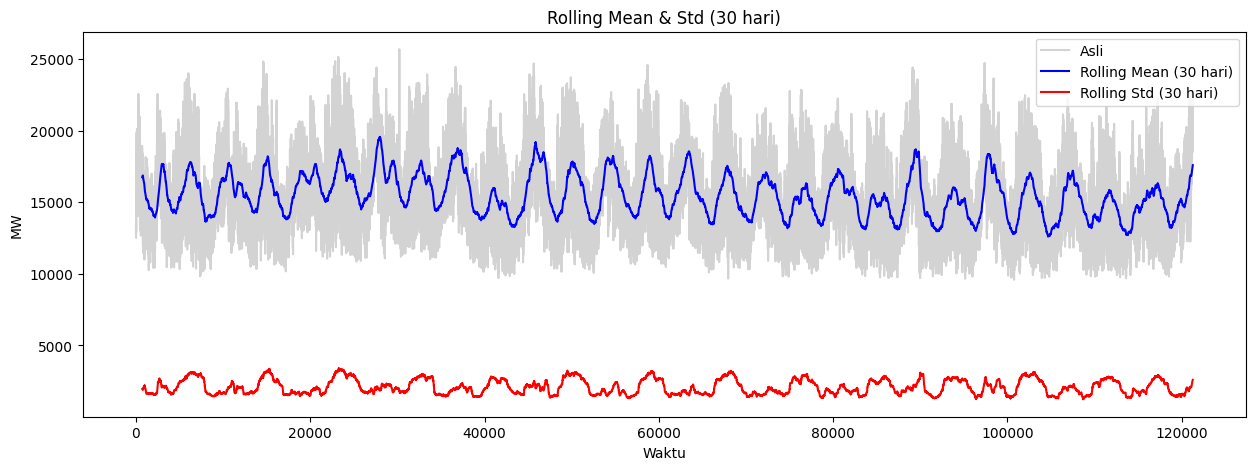

<Figure size 1200x400 with 0 Axes>

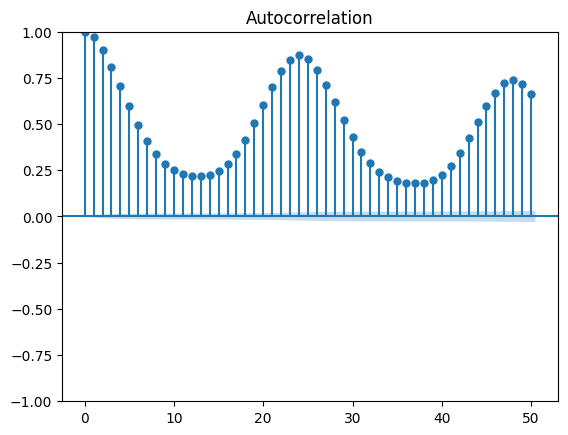

<Figure size 1200x400 with 0 Axes>

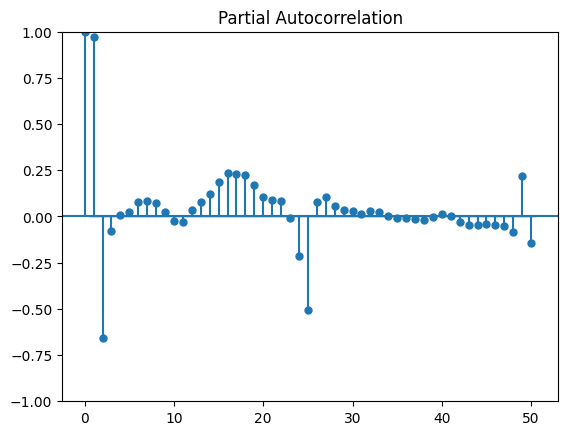

In [99]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- 🧪 1. Uji Stasioneritas (ADF Test) ---
result = adfuller(df['AEP_MW'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))

if result[1] < 0.05:
    print("❗ Data stasioner (tolak H0)")
else:
    print("⚠️ Data tidak stasioner (gagal tolak H0)")

# --- 📊 2. Rolling Mean & Std ---
rolling_mean = df['AEP_MW'].rolling(window=24*30).mean()   # window 30 hari
rolling_std = df['AEP_MW'].rolling(window=24*30).std()

plt.figure(figsize=(15,5))
plt.plot(df['AEP_MW'], color='lightgray', label='Asli')
plt.plot(rolling_mean, color='blue', label='Rolling Mean (30 hari)')
plt.plot(rolling_std, color='red', label='Rolling Std (30 hari)')
plt.title('Rolling Mean & Std (30 hari)')
plt.xlabel('Waktu')
plt.ylabel('MW')
plt.legend()
plt.show()

# --- 🔁 3. Autocorrelation (ACF & PACF) ---
plt.figure(figsize=(12,4))
plot_acf(df['AEP_MW'].dropna(), lags=50)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df['AEP_MW'].dropna(), lags=50)
plt.show()


In [78]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Jadikan kolom Datetime sebagai index (harus dilakukan agar bisa resample)
df.set_index('Datetime', inplace=True)

# Resample ke harian (ambil rata-rata konsumsi per hari)
daily_series = df['AEP_MW'].resample('D').mean()

# Cek hasil
print(daily_series.head())

Datetime
2004-10-01    14284.521739
2004-10-02    12999.875000
2004-10-03    12227.083333
2004-10-04    14309.041667
2004-10-05    14439.708333
Freq: D, Name: AEP_MW, dtype: float64


<Figure size 1200x400 with 0 Axes>

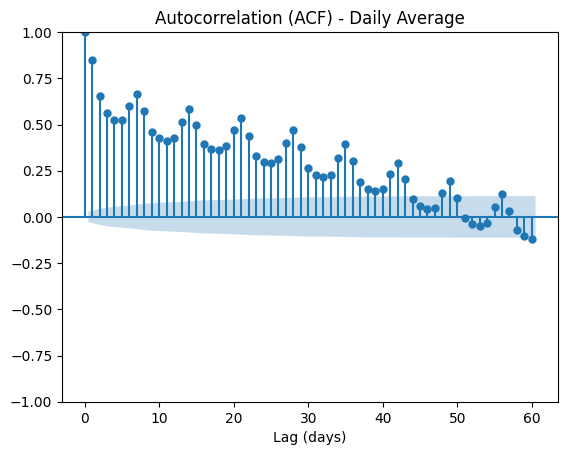

<Figure size 1200x400 with 0 Axes>

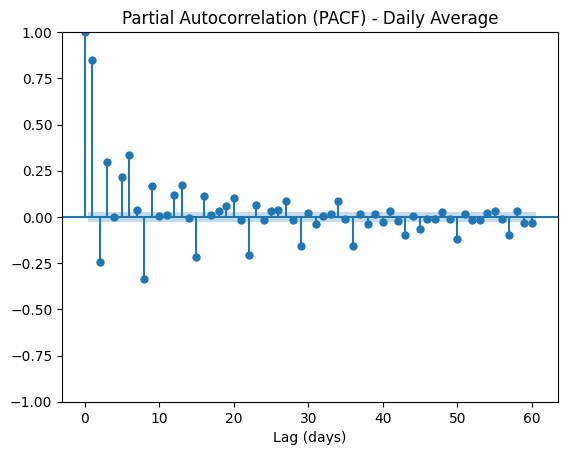

In [79]:
# Plot daily series
plt.figure(figsize=(12,4))
plot_acf(daily_series, lags=60)
plt.title('Autocorrelation (ACF) - Daily Average')
plt.xlabel('Lag (days)')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(daily_series, lags=60, method='ywm')
plt.title('Partial Autocorrelation (PACF) - Daily Average')
plt.xlabel('Lag (days)')
plt.show()


#### Read Data Country Temperature

In [80]:
country_temp = pd.read_csv('../data/datasets/city_temperature.csv')
country_temp

C:\Users\72531\AppData\Local\Temp\ipykernel_25756\1332514834.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  country_temp = pd.read_csv('../data/datasets/city_temperature.csv')


,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9
...,...,...,...,...,...,...,...,...
2906322,North America,US,Additional Territories,San Juan Puerto Rico,7,27,2013,82.4
2906323,North America,US,Additional Territories,San Juan Puerto Rico,7,28,2013,81.6
2906324,North America,US,Additional Territories,San Juan Puerto Rico,7,29,2013,84.2
2906325,North America,US,Additional Territories,San Juan Puerto Rico,7,30,2013,83.8


In [81]:
# Filter hanya US dan tahun 2004–2018
us_temp = country_temp[
    (country_temp['Country'] == 'US') &
    (country_temp['Year'].between(2004, 2018))
]

# Buang data tidak valid
us_temp = us_temp[us_temp['AvgTemperature'] > -30]  # buang nilai -99 atau -39.99

# Buat kolom Date
us_temp['Date'] = pd.to_datetime(us_temp[['Year','Month','Day']])

# Drop kolom tidak diperlukan
us_temp.drop(columns=['Region','State','City'], inplace=True)

# Hitung rata-rata suhu per hari
daily_temp = us_temp.groupby('Date')['AvgTemperature'].mean().reset_index()

# --- Gabungkan berdasarkan tanggal ---
daily_series.index = pd.to_datetime(daily_series.index)
daily_series = daily_series.reset_index().rename(columns={'index':'Date','Datetime':'Date'})
merged = pd.merge(daily_series, daily_temp, on='Date', how='inner')


#### Convert to Fahreinheit

In [83]:
merged['AvgTemperature'] = (merged['AvgTemperature'] - 32) * 5/9
merged

,Date,AEP_MW,AvgTemperature
0,2004-10-01,14284.521739,-8.167171
1,2004-10-02,12999.875000,-8.434414
2,2004-10-03,12227.083333,-8.720592
3,2004-10-04,14309.041667,-8.803090
4,2004-10-05,14439.708333,-9.464892
...,...,...,...
5047,2018-07-30,15368.083333,-4.430122
5048,2018-07-31,15180.291667,-4.718389
5049,2018-08-01,15151.166667,-4.315541
5050,2018-08-02,15687.666667,-4.165658


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                            AEP_MW   No. Observations:                 4992
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -39685.077
Date:                           Tue, 23 Sep 2025   AIC                          79382.153
Time:                                   10:01:59   BIC                          79421.226
Sample:                                        0   HQIC                         79395.851
                                          - 4992                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
AvgTemperature  -432.1295     12.357    -34.972      0.000    -456.348    -407.911
ar.L1             -0.3108      

d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


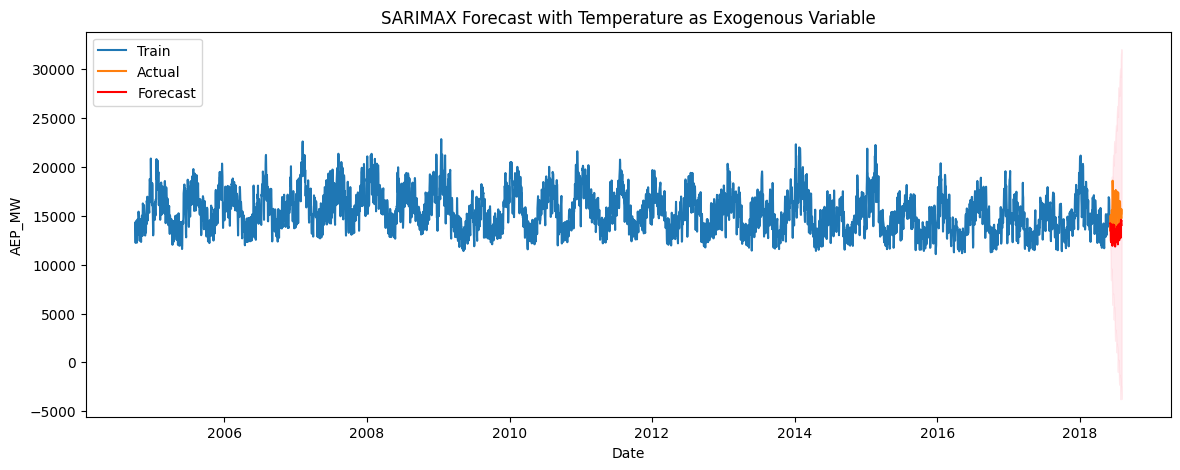

RMSE: 2625.021000398022
RMSE: 2625.021000398022
MAPE: 13.90%


In [85]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np

# Set Date as index and resample ke harian (agar lebih stabil)
if 'Date' in merged.columns:
    merged['Date'] = pd.to_datetime(merged['Date'])
    merged = merged.set_index('Date')
else:
    # Jika sudah jadi index, cukup pastikan index-nya datetime
    merged.index = pd.to_datetime(merged.index)

merged = merged.sort_index()

# Ensure numeric columns before resampling
numeric_columns = ['AEP_MW', 'AvgTemperature']
daily = merged[numeric_columns].resample('D').mean()
daily = daily.dropna()
daily = daily.sort_index()

# Pisahkan data train dan test
train = daily.iloc[:-60]   # semua kecuali 30 hari terakhir
test  = daily.iloc[-60:]   # 30 hari terakhir

# Fit SARIMAX: endog = AEP_MW, exog = temperature
model = SARIMAX(
    train['AEP_MW'],
    exog=train[['AvgTemperature']],
    order=(1,1,1),      # (p,d,q)
    seasonal_order=(1,1,1,7),  # (P,D,Q,s) -> musiman mingguan
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)
print(result.summary())

# Forecast 30 hari ke depan (sama panjang dengan test)
forecast = result.get_forecast(
    steps=len(test),
    exog=test[['AvgTemperature']]
)

pred_mean = forecast.predicted_mean
pred_mean.index = test.index  # <-- tambahkan baris ini
pred_ci = forecast.conf_int()
pred_ci.index = test.index    # <-- dan ini juga

# Plot hasilnya
plt.figure(figsize=(14,5))
plt.plot(train.index, train['AEP_MW'], label='Train')
plt.plot(test.index, test['AEP_MW'], label='Actual')
plt.plot(pred_mean.index, pred_mean, label='Forecast', color='red')
plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], 
                 color='pink', alpha=0.3)
plt.title('SARIMAX Forecast with Temperature as Exogenous Variable')
plt.xlabel('Date')
plt.ylabel('AEP_MW')
plt.legend()
plt.show()

# Hitung error
rmse = np.sqrt(mean_squared_error(test['AEP_MW'], pred_mean))
print("RMSE:", rmse)

# Hitung RMSE
rmse = np.sqrt(mean_squared_error(test['AEP_MW'], pred_mean))
print("RMSE:", rmse)

# Hitung MAPE
mape = np.mean(np.abs((test['AEP_MW'] - pred_mean) / test['AEP_MW'])) * 100
print("MAPE: {:.2f}%".format(mape))

In [86]:
# RMSE dalam persen relatif terhadap rata-rata aktual
rmse_pct = (rmse / test['AEP_MW'].mean()) * 100
print("RMSE (%): {:.2f}%".format(rmse_pct))


RMSE (%): 16.74%


C:\Users\72531\AppData\Local\Temp\ipykernel_25756\2260142762.py:8: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_avg = merged['AEP_MW'].resample('Y').mean()


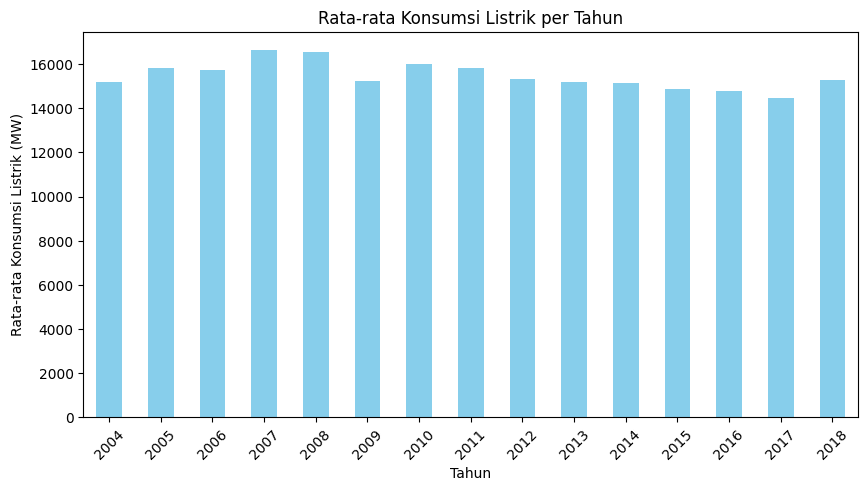

In [87]:
import matplotlib.pyplot as plt
import pandas as pd

# Pastikan index datetime
merged.index = pd.to_datetime(merged.index)

# Rata-rata konsumsi listrik per tahun
yearly_avg = merged['AEP_MW'].resample('Y').mean()

# Simpan hasil resample ke DataFrame agar bisa kembalikan index
yearly_df = yearly_avg.to_frame()
yearly_df.index.name = 'Date'

# Plot grafik per tahun
plt.figure(figsize=(10,5))
yearly_df['AEP_MW'].plot(kind='bar', color='skyblue')
plt.title('Rata-rata Konsumsi Listrik per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Konsumsi Listrik (MW)')
plt.xticks(
    ticks=range(len(yearly_df.index)),
    labels=[str(d.year) for d in yearly_df.index],
    rotation=45
)
plt.show()

# Mengembalikan index Date ke merged (jika sebelumnya diubah)
merged.index.name = 'Date'



Date
2004-10-01   -8.167171
2004-10-02   -8.434414
2004-10-03   -8.720592
2004-10-04   -8.803090
2004-10-05   -9.464892
                ...   
2018-07-30   -4.430122
2018-07-31   -4.718389
2018-08-01   -4.315541
2018-08-02   -4.165658
2018-08-03   -3.897361
Name: AvgTemperature, Length: 5052, dtype: float64
                  AEP_MW  AvgTemperature
AEP_MW          1.000000       -0.259014
AvgTemperature -0.259014        1.000000


C:\Users\72531\AppData\Local\Temp\ipykernel_25756\903519742.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = merged['AEP_MW'].resample('M').mean()


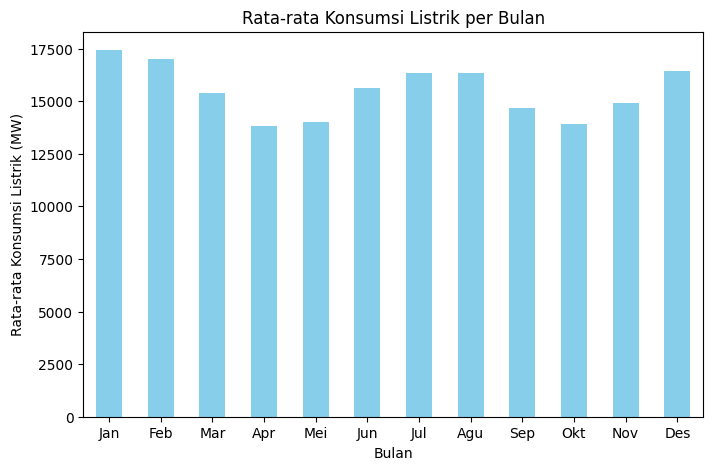

Bulan dengan konsumsi listrik rata-rata tertinggi: 1


In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print(merged['AvgTemperature'])
# --- 1. Scatter plot suhu vs konsumsi listrik ---
print(daily[['AEP_MW','AvgTemperature']].corr())

# --- 2. Rata-rata konsumsi listrik per bulan ---
# Pastikan kolom datetime menjadi index
merged = merged.copy()
merged.index = pd.to_datetime(merged.index)

monthly_avg = merged['AEP_MW'].resample('M').mean()
monthly_avg_grouped = monthly_avg.groupby(monthly_avg.index.month).mean()

plt.figure(figsize=(8,5))
monthly_avg_grouped.plot(kind='bar', color='skyblue')
plt.title('Rata-rata Konsumsi Listrik per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Konsumsi Listrik (MW)')
plt.xticks(
    ticks=range(0,12),
    labels=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'],
    rotation=0
)
plt.show()

# Menampilkan bulan dengan konsumsi rata-rata tertinggi
bulan_tertinggi = monthly_avg_grouped.idxmax()
print("Bulan dengan konsumsi listrik rata-rata tertinggi:", bulan_tertinggi)


In [89]:
merged

,AEP_MW,AvgTemperature
Date,,
2004-10-01,14284.521739,-8.167171
2004-10-02,12999.875000,-8.434414
2004-10-03,12227.083333,-8.720592
2004-10-04,14309.041667,-8.803090
2004-10-05,14439.708333,-9.464892
...,...,...
2018-07-30,15368.083333,-4.430122
2018-07-31,15180.291667,-4.718389
2018-08-01,15151.166667,-4.315541


In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Reset index to make Date a column
merged = merged.reset_index()

# Tambahkan kolom Year dan Month
merged['Year'] = merged['Date'].dt.year
merged['Month'] = merged['Date'].dt.month

# Fungsi untuk menentukan musim
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

merged['Season'] = merged['Month'].apply(get_season)

# Set Date back as index if needed
merged.set_index('Date', inplace=True)
merged

,AEP_MW,AvgTemperature,Year,Month,Season
Date,,,,,
2004-10-01,14284.521739,-8.167171,2004,10,Autumn
2004-10-02,12999.875000,-8.434414,2004,10,Autumn
2004-10-03,12227.083333,-8.720592,2004,10,Autumn
2004-10-04,14309.041667,-8.803090,2004,10,Autumn
2004-10-05,14439.708333,-9.464892,2004,10,Autumn
...,...,...,...,...,...
2018-07-30,15368.083333,-4.430122,2018,7,Summer
2018-07-31,15180.291667,-4.718389,2018,7,Summer
2018-08-01,15151.166667,-4.315541,2018,8,Summer


In [91]:
seasonal_trend = merged.groupby(['Year', 'Season']).agg({
    'AvgTemperature': 'mean',
    'AEP_MW': 'mean'
}).reset_index()
seasonal_trend

,Year,Season,AvgTemperature,AEP_MW
0,2004,Autumn,-11.030839,14380.872594
1,2004,Winter,-15.717938,16737.720430
2,2005,Autumn,-9.269038,14967.695174
3,2005,Spring,-10.839026,14552.628879
4,2005,Summer,-4.298492,16794.281250
5,2005,Winter,-15.995782,17072.689352
6,2006,Autumn,-10.062280,14868.604117
7,2006,Spring,-10.144367,14789.139473
8,2006,Summer,-4.262244,16674.568841
9,2006,Winter,-14.962588,16624.195833


C:\Users\72531\AppData\Local\Temp\ipykernel_25756\2968913872.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


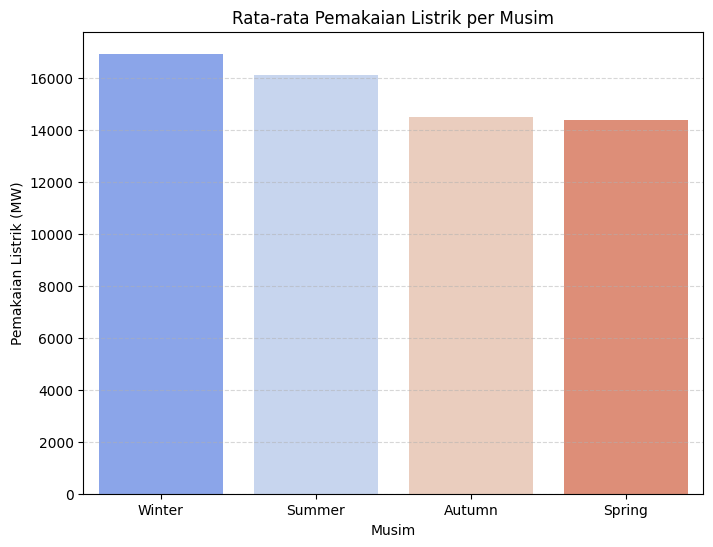

In [92]:
avg_per_season = seasonal_trend.groupby('Season')['AEP_MW'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    x=avg_per_season.index,
    y=avg_per_season.values,
    palette='coolwarm'
)
plt.title('Rata-rata Pemakaian Listrik per Musim')
plt.xlabel('Musim')
plt.ylabel('Pemakaian Listrik (MW)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

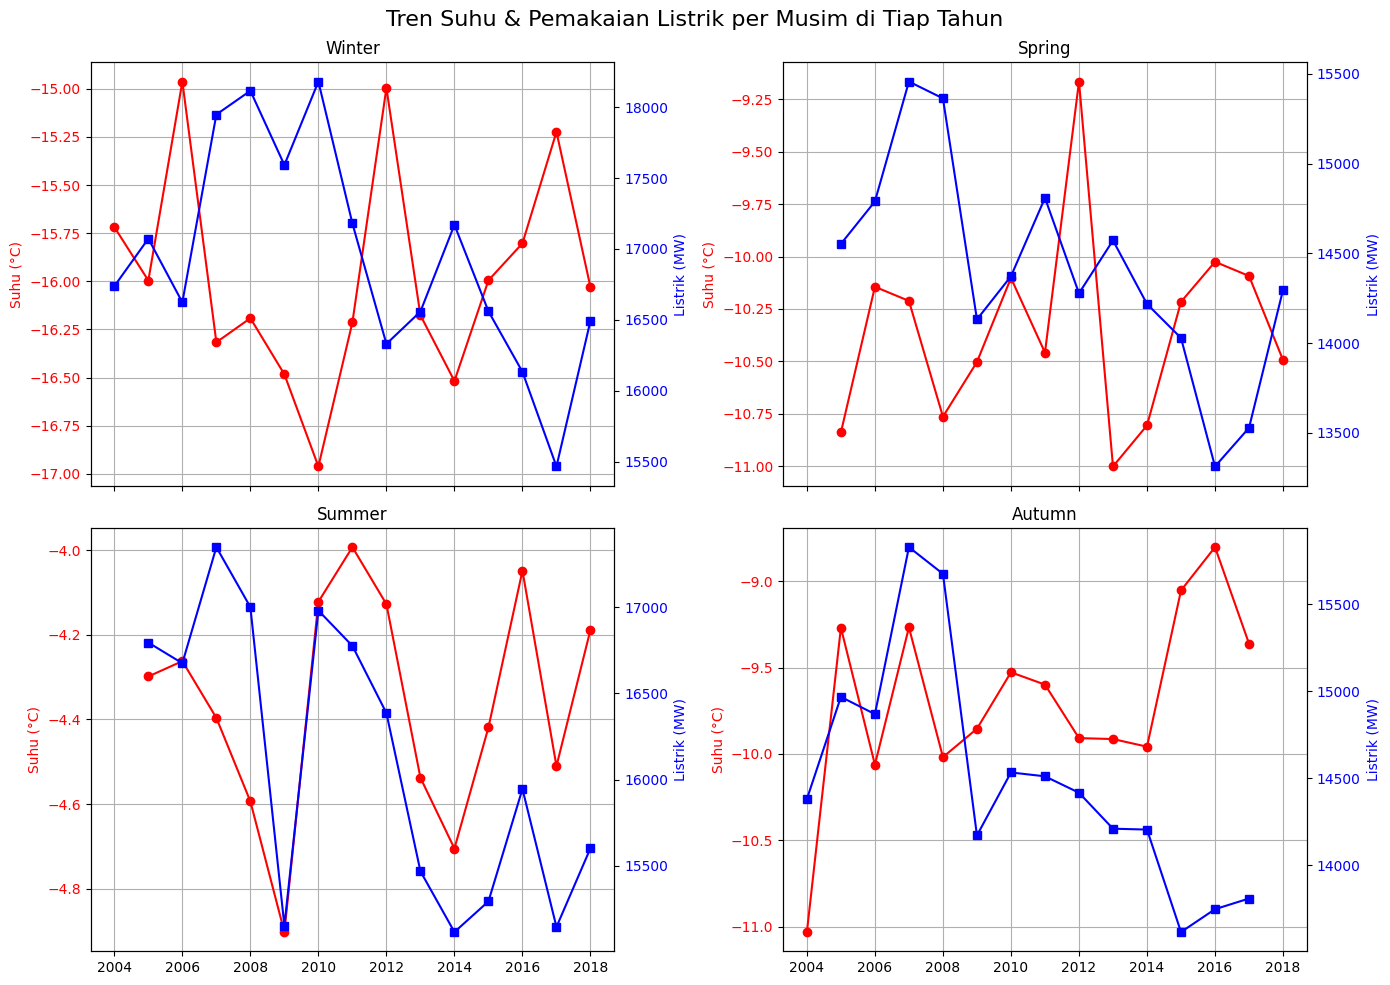

In [93]:
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

# Hitung rata-rata AEP_MW per musim


for i, season in enumerate(seasons):
    ax = axes[i]
    data = seasonal_trend[seasonal_trend['Season'] == season].dropna()
    
    if len(data) > 0:  # Only plot if we have data
        # Suhu (kiri)
        ax.plot(data['Year'], data['AvgTemperature'], color='red', marker='o', label='Suhu (°C)')
        ax.set_ylabel('Suhu (°C)', color='red')
        ax.tick_params(axis='y', labelcolor='red')
        
        # Listrik (kanan)
        if 'AEP_MW' in data.columns:
            ax2 = ax.twinx()
            ax2.plot(data['Year'], data['AEP_MW'], color='blue', marker='s', label='Listrik (MW)')
            ax2.set_ylabel('Listrik (MW)', color='blue')
            ax2.tick_params(axis='y', labelcolor='blue')
        
        ax.set_title(f'{season}')
        ax.grid(True)

plt.suptitle('Tren Suhu & Pemakaian Listrik per Musim di Tiap Tahun', fontsize=16)
plt.tight_layout()
plt.show()


=== Musim: Autumn ===


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an

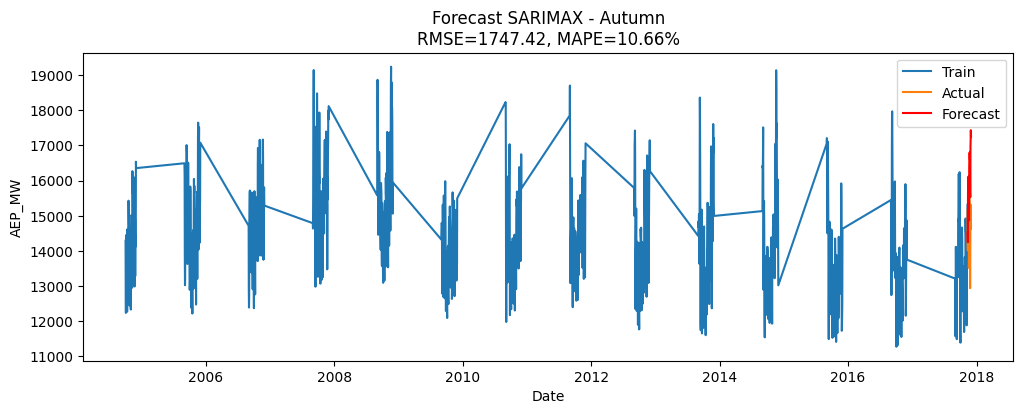

d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


=== Musim: Winter ===


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


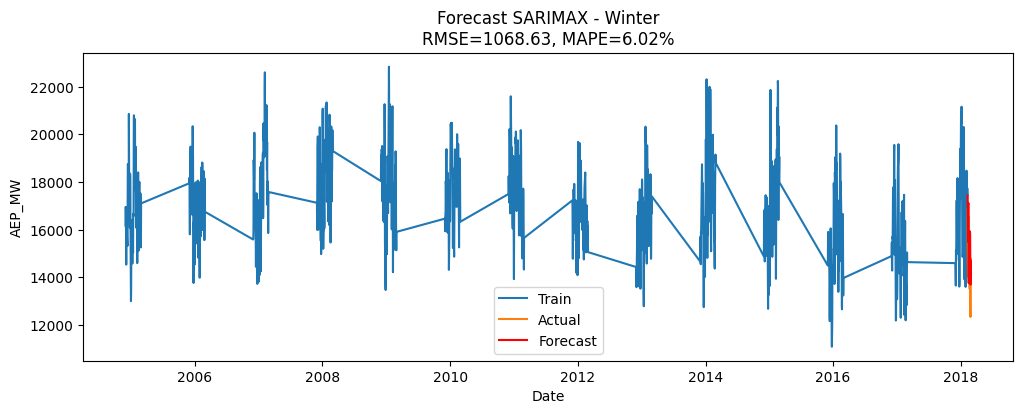

d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


=== Musim: Spring ===


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


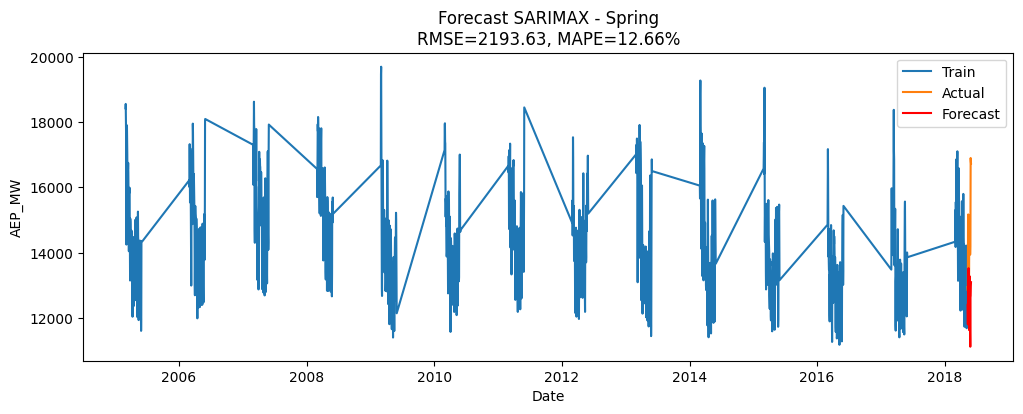

d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


=== Musim: Summer ===


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


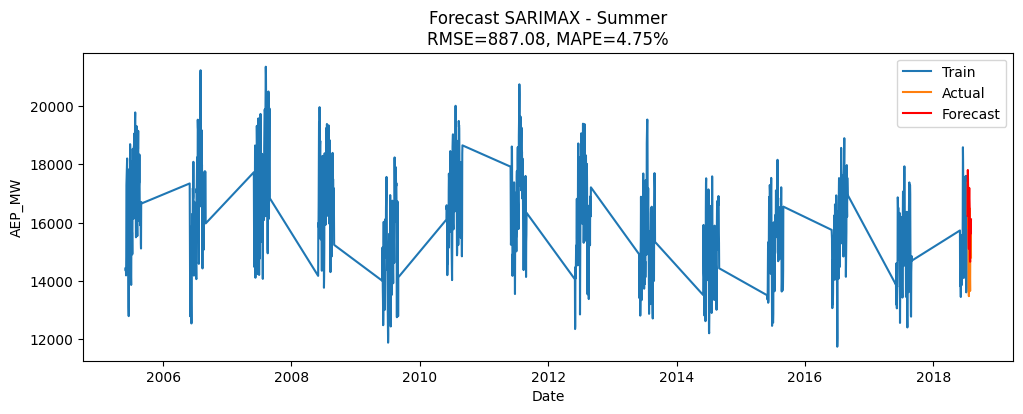

Autumn: RMSE=1747.42, MAPE=10.66%
Winter: RMSE=1068.63, MAPE=6.02%
Spring: RMSE=2193.63, MAPE=12.66%
Summer: RMSE=887.08, MAPE=4.75%


In [94]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan kolom Date adalah datetime & jadi index
if 'Date' in merged.columns:
    merged['Date'] = pd.to_datetime(merged['Date'])
    merged = merged.set_index('Date')
else:
    # Jika sudah jadi index, cukup pastikan index-nya datetime
    merged.index = pd.to_datetime(merged.index)

merged = merged.sort_index()

# Hanya pakai kolom penting
numeric_cols = ['AEP_MW','AvgTemperature']
data = merged[['AEP_MW','AvgTemperature', 'Season']].dropna()

# Dictionary untuk simpan hasil
results_per_season = {}

# Loop tiap musim
for season in data['Season'].unique():
    print(f"=== Musim: {season} ===")

    # Ambil data khusus musim ini
    sub = data[data['Season']==season].copy()
    
    # Hanya ambil kolom numerik sebelum resample
    sub = sub[['AEP_MW','AvgTemperature']]

    # Resample harian & hilangkan NaN
    sub = sub.resample('D').mean().dropna()

    # Skip jika data terlalu sedikit
    if len(sub) < 20:
        print(f"Data terlalu sedikit untuk {season}")
        continue

    # Train-test split (misal: 20 hari terakhir sebagai test)
    train = sub.iloc[:-20]
    test  = sub.iloc[-20:]

    # Fit SARIMAX
    model = SARIMAX(
        train['AEP_MW'],
        exog=train[['AvgTemperature']],
        order=(1,1,1),
        seasonal_order=(1,1,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    # Forecast
    forecast = result.get_forecast(steps=len(test), exog=test[['AvgTemperature']])
    pred = forecast.predicted_mean
    pred.index = test.index

    # Hitung error
    rmse = np.sqrt(mean_squared_error(test['AEP_MW'], pred))
    mape = mean_absolute_percentage_error(test['AEP_MW'], pred)*100

    # Simpan hasil
    results_per_season[season] = {
        'train': train, 'test': test, 'pred': pred,
        'rmse': rmse, 'mape': mape
    }

    # Plot
    plt.figure(figsize=(12,4))
    plt.plot(train.index, train['AEP_MW'], label='Train')
    plt.plot(test.index, test['AEP_MW'], label='Actual')
    plt.plot(pred.index, pred, color='red', label='Forecast')
    plt.title(f'Forecast SARIMAX - {season}\nRMSE={rmse:.2f}, MAPE={mape:.2f}%')
    plt.xlabel('Date')
    plt.ylabel('AEP_MW')
    plt.legend()
    plt.show()

# Cetak ringkasan skor
for s, res in results_per_season.items():
    print(f"{s}: RMSE={res['rmse']:.2f}, MAPE={res['mape']:.2f}%")


=== Forecast Musim: Autumn ===


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an

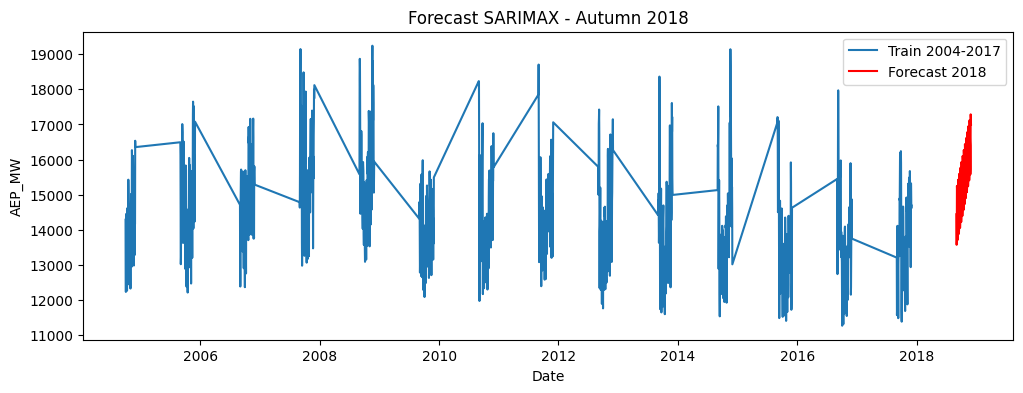

d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


=== Forecast Musim: Winter ===


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


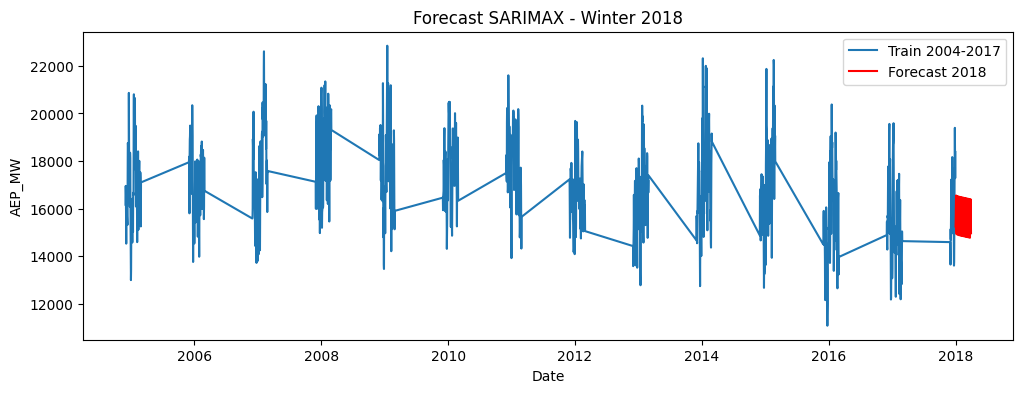

d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


=== Forecast Musim: Spring ===


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


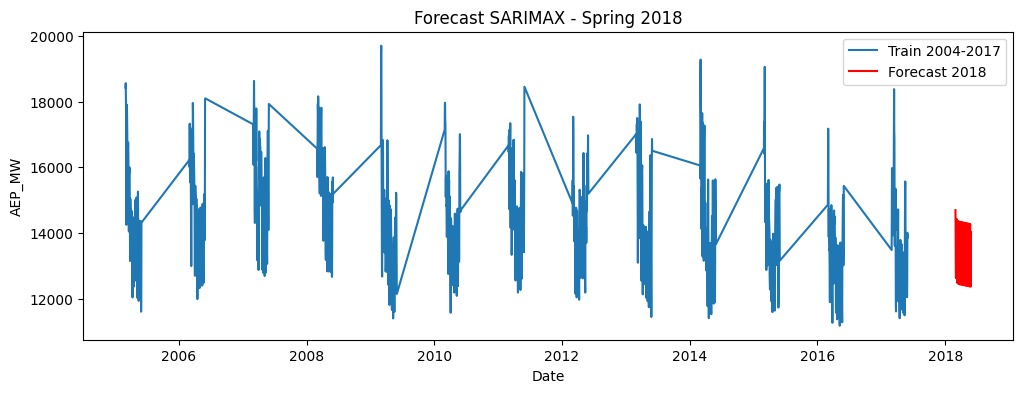

d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


=== Forecast Musim: Summer ===


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


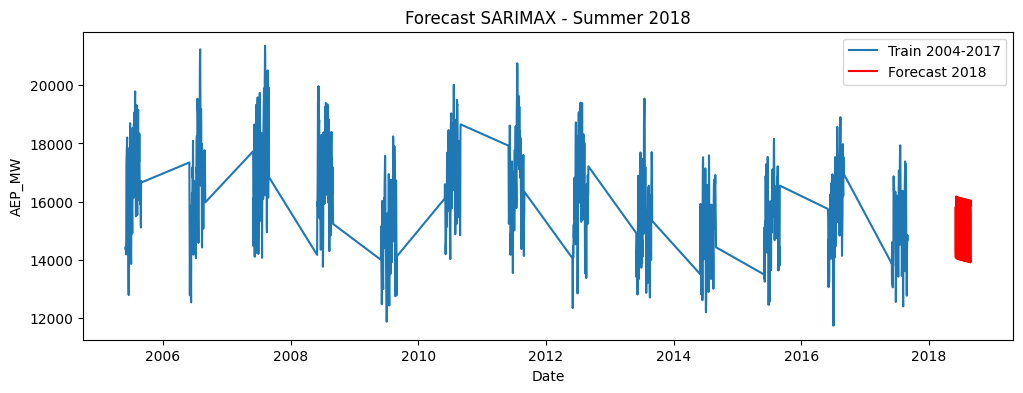


=== Total Pemakaian Listrik 2018 (Prediksi) ===
Autumn: 1380772.13 MW-day
Winter: 1390832.03 MW-day
Spring: 1211911.81 MW-day
Summer: 1366601.30 MW-day
TOTAL 2018: 5350117.28 MW-day


In [95]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# Pastikan index datetime
merged.index = pd.to_datetime(merged.index)
merged = merged.sort_index()

# Ambil kolom penting
data = merged[['AEP_MW', 'AvgTemperature', 'Season']].dropna()

forecast_2018 = {}
total_2018 = {}

# Loop tiap musim
for season in data['Season'].unique():
    print(f"=== Forecast Musim: {season} ===")
    
    # Ambil data musim ini
    sub = data[data['Season'] == season].copy()
    sub = sub[['AEP_MW','AvgTemperature']]
    sub = sub.resample('D').mean().dropna()
    
    if len(sub) < 100:
        print(f"Data terlalu sedikit untuk {season}")
        continue
    
    # Train = semua data sampai 2017
    train = sub[sub.index.year <= 2017]
    
    # Tentukan jumlah hari di musim 2018
    # Musim rata-rata panjangnya 90 hari (kurang lebih)
    steps = 90
    
    # Exog untuk 2018 → gunakan rata-rata suhu historis musim tsb
    avg_temp_future = pd.DataFrame({
        'AvgTemperature': [train['AvgTemperature'].mean()] * steps
    })
    
    # Fit SARIMAX
    model = SARIMAX(
        train['AEP_MW'],
        exog=train[['AvgTemperature']],
        order=(1,1,1),
        seasonal_order=(1,1,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    result = model.fit(disp=False)
    
    # Forecast 2018
    forecast = result.get_forecast(steps=steps, exog=avg_temp_future)
    pred = forecast.predicted_mean
    
    # Buat index tanggal forecast (2018)
    start_date = f'2018-{"01" if season=="Winter" else "03" if season=="Spring" else "06" if season=="Summer" else "09"}-01'
    pred.index = pd.date_range(start=start_date, periods=steps, freq='D')
    
    forecast_2018[season] = pred
    
    # Hitung total pemakaian listrik musim ini (integral)
    days = np.arange(len(pred))
    total_energy = trapezoid(pred.values, days)
    total_2018[season] = total_energy
    
    # Plot
    plt.figure(figsize=(12,4))
    plt.plot(train.index, train['AEP_MW'], label='Train 2004-2017')
    plt.plot(pred.index, pred, color='red', label='Forecast 2018')
    plt.title(f'Forecast SARIMAX - {season} 2018')
    plt.xlabel('Date')
    plt.ylabel('AEP_MW')
    plt.legend()
    plt.show()

# === Total setahun 2018 ===
total_year_2018 = sum(total_2018.values())
print("\n=== Total Pemakaian Listrik 2018 (Prediksi) ===")
for season, val in total_2018.items():
    print(f"{season}: {val:.2f} MW-day")
print(f"TOTAL 2018: {total_year_2018:.2f} MW-day")

In [96]:
# Ubah total dari MW-day ke MWh
total_2018_hours = {season: val * 24 for season, val in total_2018.items()}
total_year_2018_hours = sum(total_2018_hours.values())

print("\n=== Total Pemakaian Listrik 2018 (Prediksi) ===")
for season, val in total_2018_hours.items():
    print(f"{season}: {val:.2f} MWh")
print(f"TOTAL 2018: {total_year_2018_hours:.2f} MWh")



=== Total Pemakaian Listrik 2018 (Prediksi) ===
Autumn: 33138531.03 MWh
Winter: 33379968.81 MWh
Spring: 29085883.50 MWh
Summer: 32798431.31 MWh
TOTAL 2018: 128402814.65 MWh
